# ML: Predicting dJ/dV Model Parameters from Composition

Features: Pt, Pd, Au, Ir (atomic fractions)  
Targets: k, V₀, u₁, s₁, A₁, A₂ (parameters of the dJ/dV model fit)

Pipeline:
1. Load and inspect `composition_djdV.csv`
2. Random Forest with randomized hyperparameter search (5×5-fold CV)
3. Per-sample comparison of true vs predicted dJ/dV curves
4. Quaternary simplex visualizations of each predicted parameter

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from sklearn.model_selection import train_test_split, RandomizedSearchCV, RepeatedKFold
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

SEED    = 42
X_COLS  = ['Pt', 'Pd', 'Au', 'Ir']
Y_COLS  = ['k', 'V0', 'u1', 's1', 'A1', 'A2']


## 1. Load & Inspect

In [2]:
df = pd.read_csv('composition_djdV.csv')

print('Target summary statistics:')
print(df[Y_COLS].describe().T[['min', 'mean', 'std', '50%', 'max']])
print()
print('Skewness:')
print(df[Y_COLS].skew(numeric_only=True))


Target summary statistics:
         min       mean       std        50%        max
k   2.565668  13.028875  7.074906  11.879818  37.505568
V0  1.291925   1.686283  0.140980   1.685503   2.000000
u1  1.256555   1.367558  0.055949   1.377373   1.500000
s1  0.041803   0.077848  0.031127   0.070331   0.306183
A1  0.016740   0.056435  0.024412   0.051765   0.173634
A2  0.002149   0.019357  0.012667   0.018383   0.047514

Skewness:
k     1.496576
V0    0.618616
u1   -0.307834
s1    2.812332
A1    1.736417
A2    0.300784
dtype: float64


## 2. Clean & Split

In [3]:
df = (df[X_COLS + Y_COLS]
      .replace([np.inf, -np.inf], np.nan)
      .dropna()
      .reset_index(drop=False)
      .rename(columns={'index': 'sample_id'}))

X   = df[X_COLS].to_numpy(float)
Y   = df[Y_COLS].to_numpy(float)
ids = df['sample_id'].to_numpy()

X_train, X_test, Y_train, Y_test, id_train, id_test = train_test_split(
    X, Y, ids, test_size=0.30, random_state=SEED, shuffle=True
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')


Train: 116  |  Test: 50


## 3. Random Forest — Randomized Hyperparameter Search

In [4]:
base_rf = RandomForestRegressor(random_state=SEED, n_jobs=-1)

model = TransformedTargetRegressor(
    regressor=base_rf,
    transformer=StandardScaler()   # standardize multi-output Y
)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=SEED)

param_dist = {
    'regressor__n_estimators':     [400, 800, 1200],
    'regressor__max_depth':        [None, 5, 10, 20],
    'regressor__min_samples_split':[2, 5, 10],
    'regressor__min_samples_leaf': [2, 4, 8, 12],
    'regressor__max_features':     ['sqrt', 'log2', 1.0],
    'regressor__bootstrap':        [True],
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, Y_train)

best_model   = search.best_estimator_
best_cv_rmse = np.sqrt(-search.best_score_)

print('Best params:', search.best_params_)
print(f'Best CV RMSE: {best_cv_rmse:.4f}')


Fitting 25 folds for each of 50 candidates, totalling 1250 fits
Best params: {'regressor__n_estimators': 400, 'regressor__min_samples_split': 10, 'regressor__min_samples_leaf': 2, 'regressor__max_features': 1.0, 'regressor__max_depth': None, 'regressor__bootstrap': True}
Best CV RMSE: 2.1451


## 4. Evaluate on Held-Out Test Set

In [8]:
Y_pred = best_model.predict(X_test)

rmse = root_mean_squared_error(Y_test, Y_pred)
mae  = mean_absolute_error(Y_test, Y_pred)
r2   = r2_score(Y_test, Y_pred, multioutput='uniform_average')

print('=== Test-set metrics ===')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R²:   {r2:.4f}')

# Assemble a results frame for downstream plotting
X_test_df  = pd.DataFrame(X_test,  columns=X_COLS)
Y_test_df  = pd.DataFrame(Y_test,  columns=Y_COLS)
Y_pred_df  = pd.DataFrame(Y_pred,  columns=[f'{c}_pred' for c in Y_COLS])
results_df = pd.concat([X_test_df, Y_test_df, Y_pred_df], axis=1)
print(results_df.head())


=== Test-set metrics ===
RMSE: 1.0536
MAE:  0.7202
R²:   0.5108
       Pt      Pd      Au      Ir          k        V0        u1        s1  \
0  0.1339  0.1461  0.1110  0.6090  30.108983  1.486357  1.397963  0.097238   
1  0.5273  0.1176  0.3237  0.0314  15.398726  1.615642  1.263939  0.053091   
2  0.2435  0.1388  0.5317  0.0859  13.030246  1.730401  1.343653  0.059817   
3  0.2973  0.1163  0.5138  0.0726  11.665235  1.703237  1.339862  0.065510   
4  0.0560  0.5051  0.1957  0.2432  11.708776  1.662953  1.389543  0.074282   

         A1        A2     k_pred   V0_pred   u1_pred   s1_pred   A1_pred  \
0  0.033242  0.039157  25.905067  1.517664  1.413442  0.106982  0.033125   
1  0.026808  0.008172  11.832713  1.686340  1.268560  0.048769  0.050746   
2  0.070034  0.005404  13.327220  1.706005  1.323068  0.067255  0.053816   
3  0.045452  0.004606  12.519945  1.700151  1.307487  0.060680  0.049244   
4  0.063076  0.021549   9.874399  1.687843  1.396266  0.086302  0.063738   

    A2_pre

## 5. True vs Predicted dJ/dV Curves

Pt          0.133900
Pd          0.146100
Au          0.111000
Ir          0.609000
k          30.108983
V0          1.486357
u1          1.397963
s1          0.097238
A1          0.033242
A2          0.039157
k_pred     25.905067
V0_pred     1.517664
u1_pred     1.413442
s1_pred     0.106982
A1_pred     0.033125
A2_pred     0.035383
Name: 0, dtype: float64


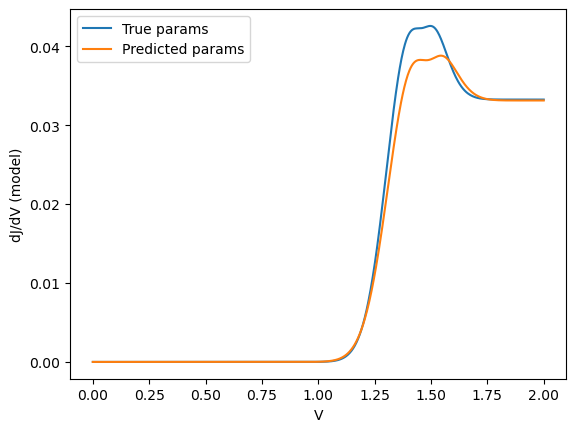

Pt          0.527300
Pd          0.117600
Au          0.323700
Ir          0.031400
k          15.398726
V0          1.615642
u1          1.263939
s1          0.053091
A1          0.026808
A2          0.008172
k_pred     11.832713
V0_pred     1.686340
u1_pred     1.268560
s1_pred     0.048769
A1_pred     0.050746
A2_pred     0.006803
Name: 1, dtype: float64


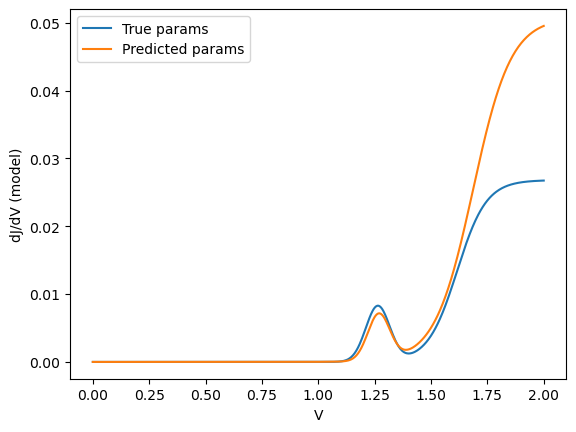

Pt          0.243500
Pd          0.138800
Au          0.531700
Ir          0.085900
k          13.030246
V0          1.730401
u1          1.343653
s1          0.059817
A1          0.070034
A2          0.005404
k_pred     13.327220
V0_pred     1.706005
u1_pred     1.323068
s1_pred     0.067255
A1_pred     0.053816
A2_pred     0.007421
Name: 2, dtype: float64


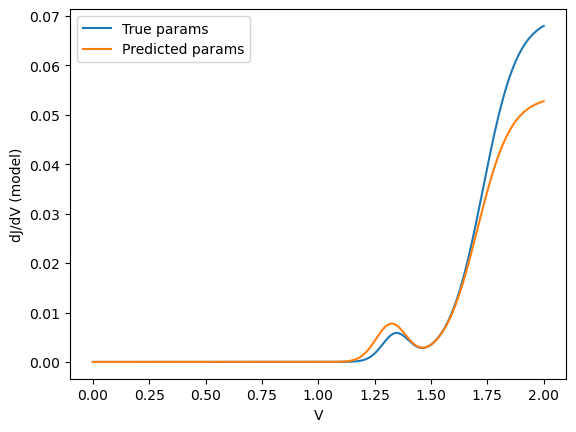

Pt          0.297300
Pd          0.116300
Au          0.513800
Ir          0.072600
k          11.665235
V0          1.703237
u1          1.339862
s1          0.065510
A1          0.045452
A2          0.004606
k_pred     12.519945
V0_pred     1.700151
u1_pred     1.307487
s1_pred     0.060680
A1_pred     0.049244
A2_pred     0.005640
Name: 3, dtype: float64


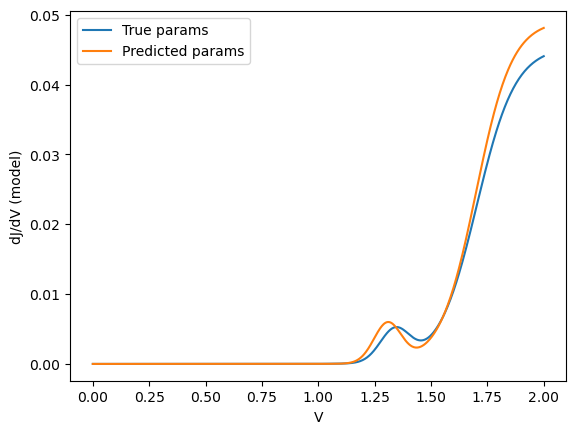

Pt          0.056000
Pd          0.505100
Au          0.195700
Ir          0.243200
k          11.708776
V0          1.662953
u1          1.389543
s1          0.074282
A1          0.063076
A2          0.021549
k_pred      9.874399
V0_pred     1.687843
u1_pred     1.396266
s1_pred     0.086302
A1_pred     0.063738
A2_pred     0.029006
Name: 4, dtype: float64


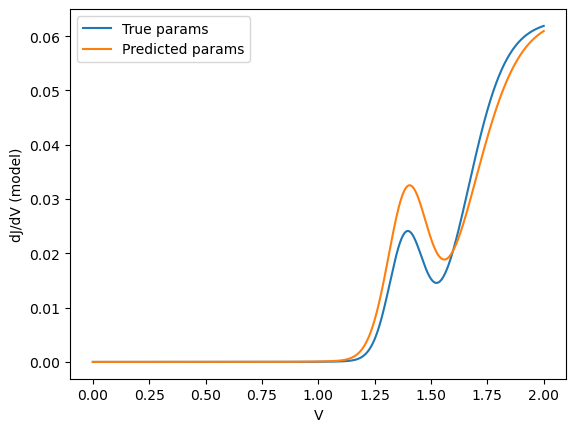

Pt         0.086800
Pd         0.086100
Au         0.555000
Ir         0.272100
k          3.260187
V0         2.000000
u1         1.422129
s1         0.080092
A1         0.078237
A2         0.019259
k_pred     7.723198
V0_pred    1.839915
u1_pred    1.399342
s1_pred    0.078381
A1_pred    0.084587
A2_pred    0.026644
Name: 5, dtype: float64


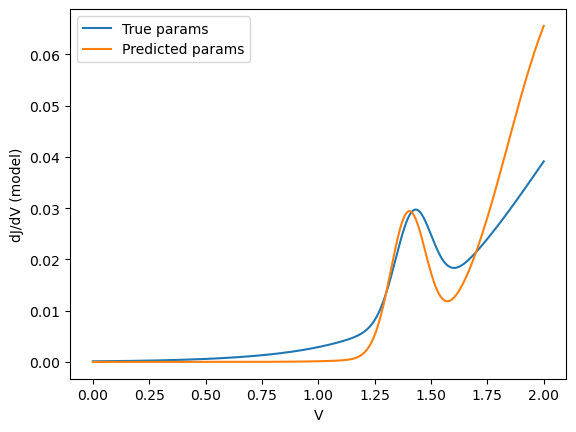

Pt          0.229900
Pd          0.145600
Au          0.511100
Ir          0.113500
k          11.881672
V0          1.733243
u1          1.334910
s1          0.054570
A1          0.065666
A2          0.005160
k_pred     12.311212
V0_pred     1.718341
u1_pred     1.357702
s1_pred     0.066881
A1_pred     0.060437
A2_pred     0.008274
Name: 6, dtype: float64


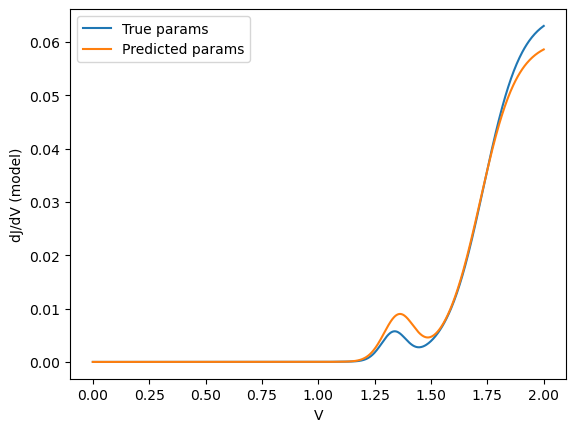

Pt          0.139700
Pd          0.092800
Au          0.611800
Ir          0.155600
k           4.102197
V0          2.000000
u1          1.383986
s1          0.051208
A1          0.080831
A2          0.011186
k_pred     10.499843
V0_pred     1.772161
u1_pred     1.372100
s1_pred     0.060754
A1_pred     0.069851
A2_pred     0.015101
Name: 7, dtype: float64


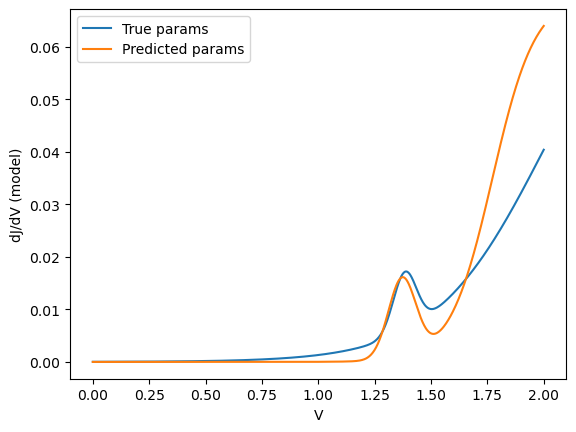

Pt          0.170400
Pd          0.223500
Au          0.099900
Ir          0.506200
k           8.488965
V0          1.642226
u1          1.425675
s1          0.114314
A1          0.050339
A2          0.033533
k_pred     25.371694
V0_pred     1.514239
u1_pred     1.406521
s1_pred     0.101852
A1_pred     0.035272
A2_pred     0.035235
Name: 8, dtype: float64


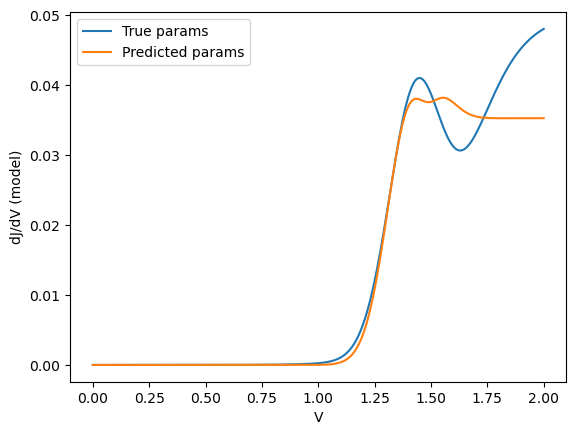

Pt          0.151500
Pd          0.073100
Au          0.073400
Ir          0.701900
k          17.313067
V0          1.567430
u1          1.445571
s1          0.128584
A1          0.026386
A2          0.034189
k_pred     25.041620
V0_pred     1.533046
u1_pred     1.427683
s1_pred     0.115189
A1_pred     0.032879
A2_pred     0.035863
Name: 9, dtype: float64


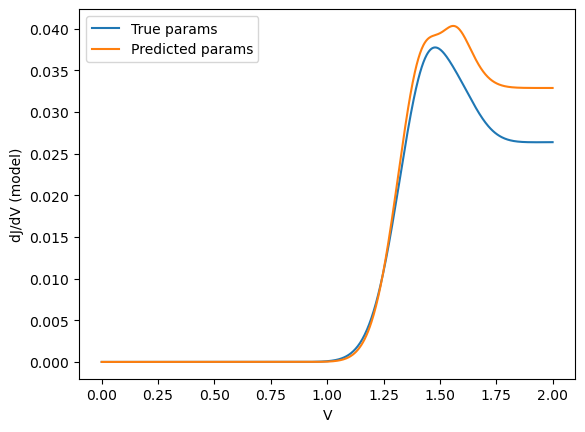

Pt         0.044700
Pd         0.337700
Au         0.314800
Ir         0.302800
k          8.903192
V0         1.654233
u1         1.400567
s1         0.090282
A1         0.061053
A2         0.035855
k_pred     8.073913
V0_pred    1.755906
u1_pred    1.402950
s1_pred    0.089616
A1_pred    0.077189
A2_pred    0.031106
Name: 10, dtype: float64


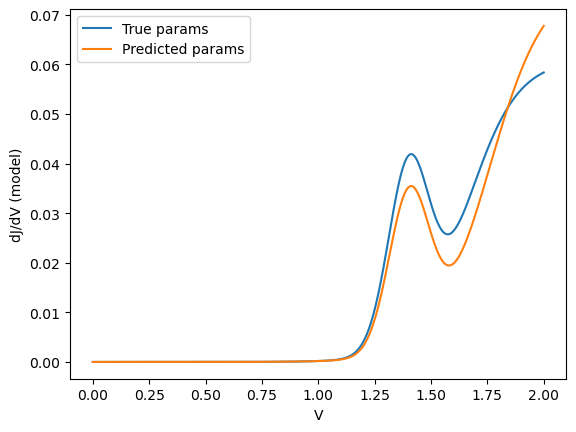

Pt          0.143800
Pd          0.239400
Au          0.478100
Ir          0.138700
k          13.593940
V0          1.692966
u1          1.367375
s1          0.069776
A1          0.063767
A2          0.014368
k_pred     11.986126
V0_pred     1.731242
u1_pred     1.361949
s1_pred     0.061765
A1_pred     0.069482
A2_pred     0.011940
Name: 11, dtype: float64


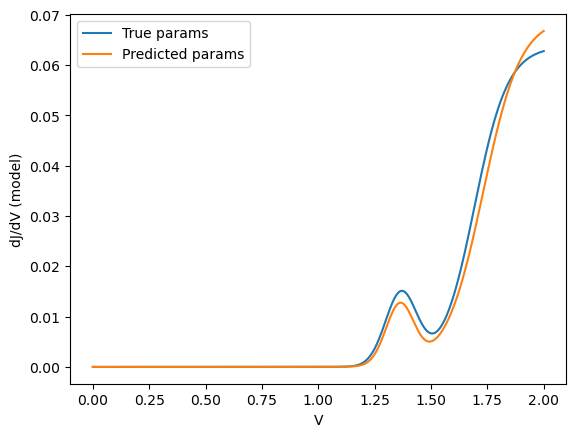

Pt          0.083100
Pd          0.097300
Au          0.482600
Ir          0.337000
k          21.228157
V0          1.463978
u1          1.392226
s1          0.091780
A1          0.026077
A2          0.026606
k_pred      8.155076
V0_pred     1.777192
u1_pred     1.405294
s1_pred     0.086820
A1_pred     0.074320
A2_pred     0.029078
Name: 12, dtype: float64


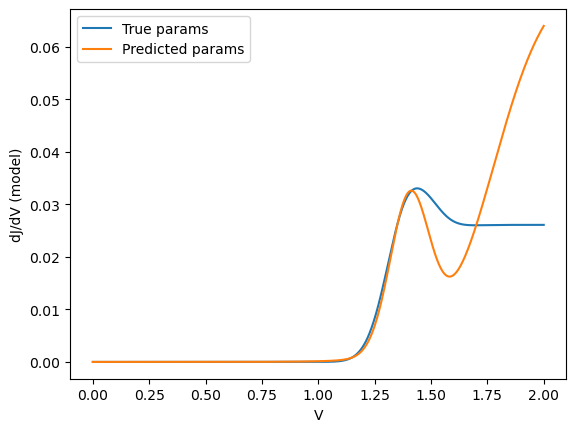

Pt          0.296300
Pd          0.103100
Au          0.519100
Ir          0.081500
k          10.972652
V0          1.714728
u1          1.297732
s1          0.057704
A1          0.060448
A2          0.005197
k_pred     12.452683
V0_pred     1.701168
u1_pred     1.308307
s1_pred     0.060415
A1_pred     0.050276
A2_pred     0.005657
Name: 13, dtype: float64


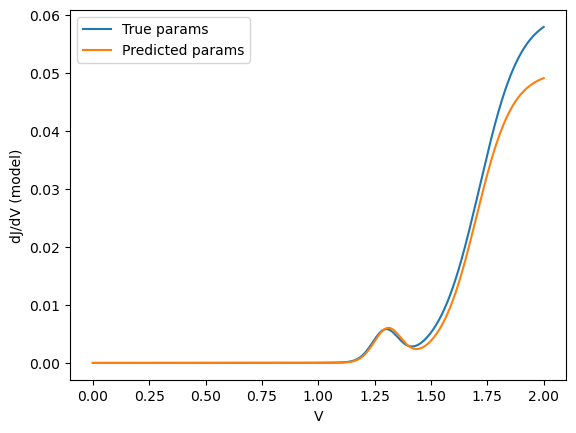

Pt          0.233100
Pd          0.357800
Au          0.319600
Ir          0.089500
k          12.864996
V0          1.699209
u1          1.362400
s1          0.080769
A1          0.058686
A2          0.020537
k_pred     15.755034
V0_pred     1.700508
u1_pred     1.320511
s1_pred     0.080359
A1_pred     0.054081
A2_pred     0.012465
Name: 14, dtype: float64


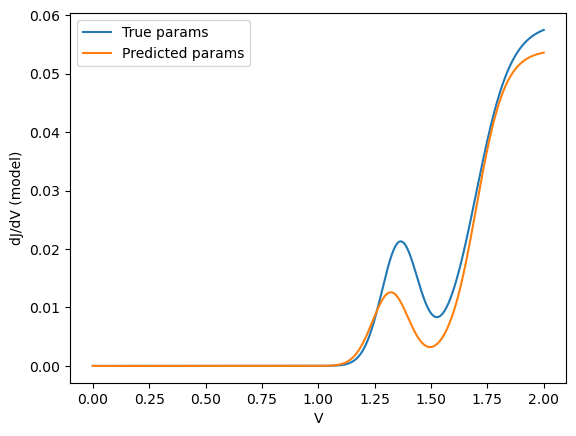

Pt          0.032500
Pd          0.148500
Au          0.381800
Ir          0.437200
k          10.712022
V0          1.550143
u1          1.415568
s1          0.103079
A1          0.040293
A2          0.037588
k_pred     25.423303
V0_pred     1.432840
u1_pred     1.419422
s1_pred     0.105507
A1_pred     0.035656
A2_pred     0.026186
Name: 15, dtype: float64


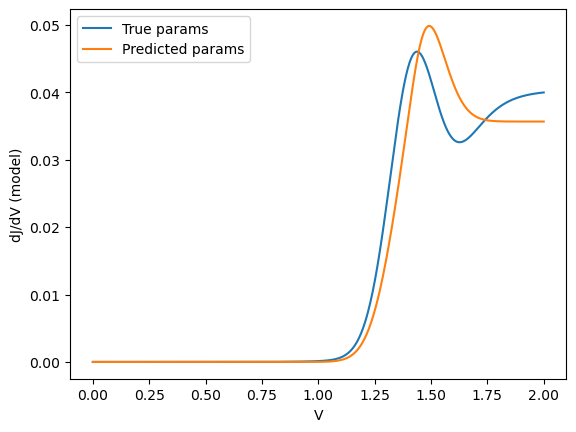

Pt          0.121600
Pd          0.210100
Au          0.138800
Ir          0.529600
k          10.612810
V0          1.549086
u1          1.408415
s1          0.101001
A1          0.028103
A2          0.023315
k_pred     26.635711
V0_pred     1.508694
u1_pred     1.406774
s1_pred     0.102425
A1_pred     0.034207
A2_pred     0.035488
Name: 16, dtype: float64


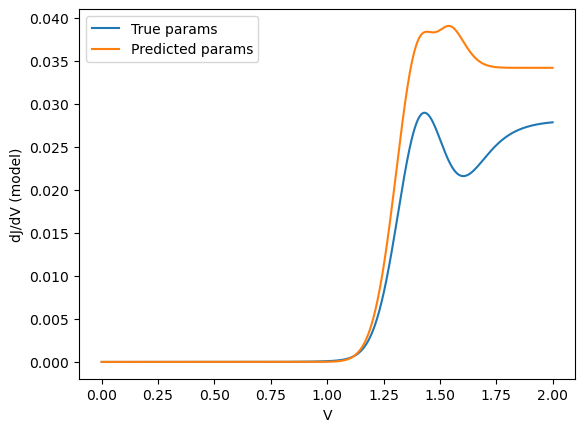

Pt          0.101500
Pd          0.182100
Au          0.319300
Ir          0.397200
k           6.618186
V0          1.675920
u1          1.410536
s1          0.098996
A1          0.052615
A2          0.029523
k_pred     20.190987
V0_pred     1.555533
u1_pred     1.403506
s1_pred     0.096459
A1_pred     0.043765
A2_pred     0.031817
Name: 17, dtype: float64


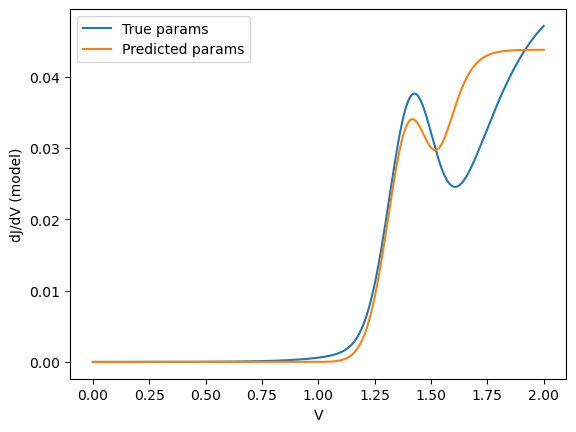

Pt          0.309700
Pd          0.233500
Au          0.046800
Ir          0.410100
k          10.854262
V0          1.557557
u1          1.401553
s1          0.097204
A1          0.035277
A2          0.024462
k_pred     12.147947
V0_pred     1.584996
u1_pred     1.405415
s1_pred     0.098003
A1_pred     0.046305
A2_pred     0.031070
Name: 18, dtype: float64


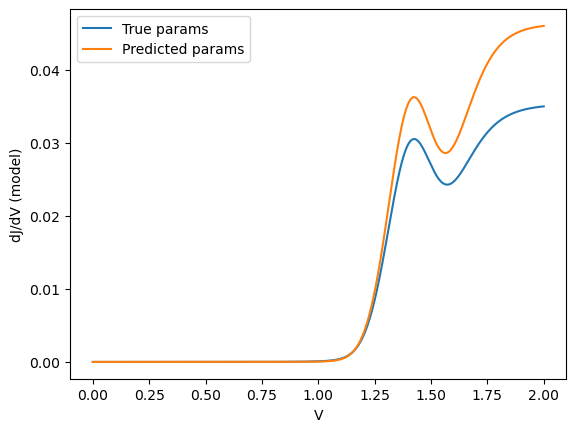

Pt          0.175100
Pd          0.128900
Au          0.569100
Ir          0.126900
k          11.465517
V0          1.684465
u1          1.368455
s1          0.056090
A1          0.036740
A2          0.010867
k_pred     12.338334
V0_pred     1.718022
u1_pred     1.358476
s1_pred     0.055822
A1_pred     0.064081
A2_pred     0.010034
Name: 19, dtype: float64


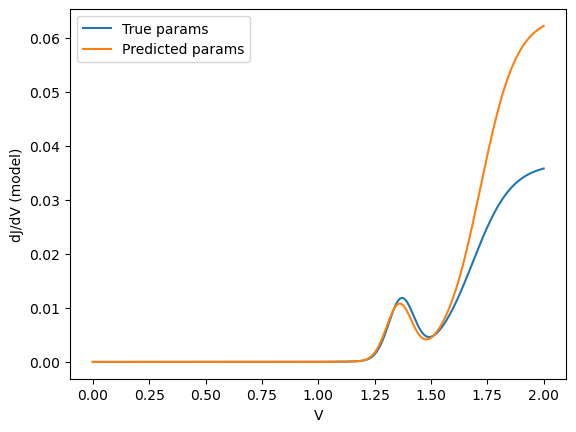

Pt          0.257300
Pd          0.078200
Au          0.582400
Ir          0.082100
k          12.669351
V0          1.695457
u1          1.358700
s1          0.045888
A1          0.042527
A2          0.005125
k_pred     13.375816
V0_pred     1.697583
u1_pred     1.320677
s1_pred     0.065384
A1_pred     0.049632
A2_pred     0.007050
Name: 20, dtype: float64


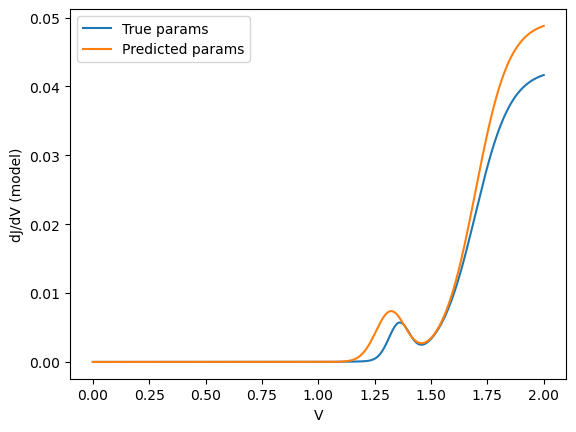

Pt          0.110000
Pd          0.105600
Au          0.625200
Ir          0.159100
k          13.512564
V0          1.703533
u1          1.372155
s1          0.052499
A1          0.068968
A2          0.016090
k_pred     10.210432
V0_pred     1.786618
u1_pred     1.375058
s1_pred     0.061726
A1_pred     0.074316
A2_pred     0.016230
Name: 21, dtype: float64


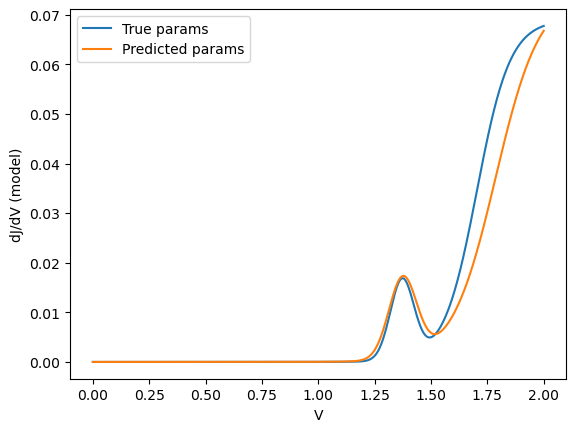

Pt          0.144400
Pd          0.337300
Au          0.364800
Ir          0.153500
k           3.390296
V0          2.000000
u1          1.385754
s1          0.080366
A1          0.095499
A2          0.021499
k_pred     10.027039
V0_pred     1.783360
u1_pred     1.375740
s1_pred     0.077058
A1_pred     0.077204
A2_pred     0.015866
Name: 22, dtype: float64


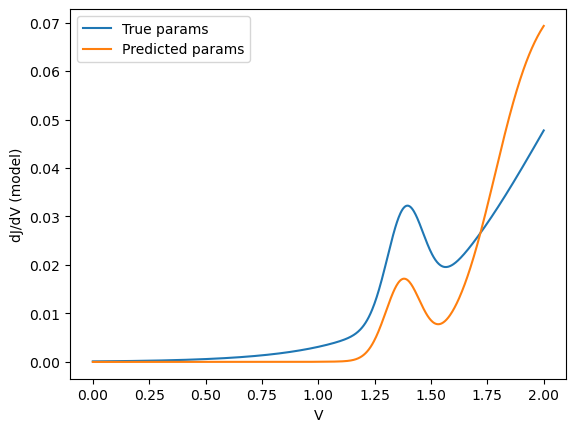

Pt          0.140600
Pd          0.142900
Au          0.463600
Ir          0.252900
k          11.476848
V0          1.685861
u1          1.374914
s1          0.069437
A1          0.059956
A2          0.022845
k_pred      8.467597
V0_pred     1.785964
u1_pred     1.393656
s1_pred     0.078530
A1_pred     0.074553
A2_pred     0.024540
Name: 23, dtype: float64


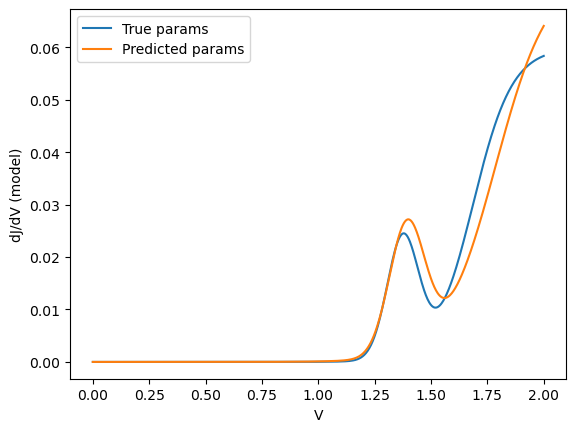

Pt         0.089700
Pd         0.232000
Au         0.364700
Ir         0.315300
k          3.045928
V0         2.000000
u1         1.462200
s1         0.118149
A1         0.087834
A2         0.024878
k_pred     7.380393
V0_pred    1.742766
u1_pred    1.403965
s1_pred    0.089580
A1_pred    0.069556
A2_pred    0.028230
Name: 24, dtype: float64


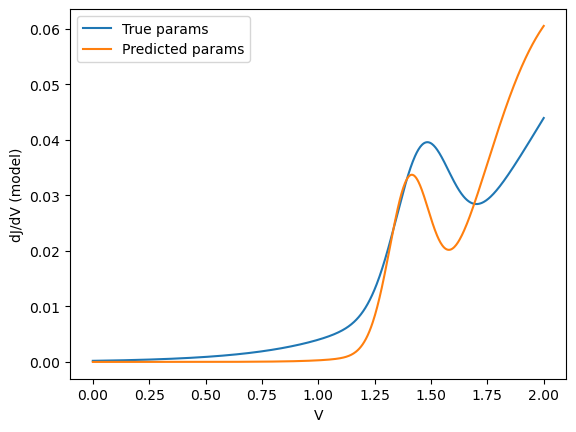

Pt         0.118900
Pd         0.249500
Au         0.333300
Ir         0.298300
k          4.115759
V0         2.000000
u1         1.392592
s1         0.080794
A1         0.134038
A2         0.027781
k_pred     7.465608
V0_pred    1.775098
u1_pred    1.397680
s1_pred    0.084899
A1_pred    0.075883
A2_pred    0.025944
Name: 25, dtype: float64


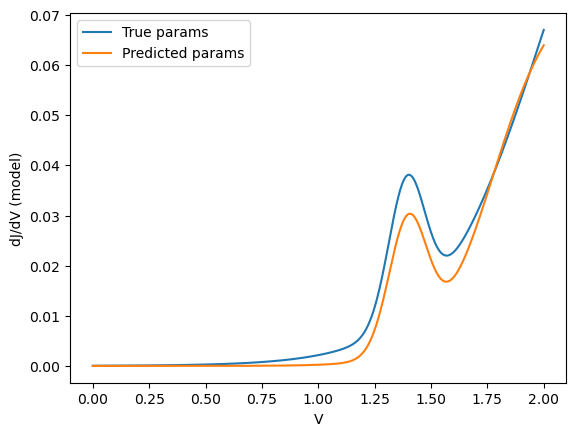

Pt          0.319400
Pd          0.360500
Au          0.265300
Ir          0.054900
k          12.336149
V0          1.698814
u1          1.274108
s1          0.055138
A1          0.066015
A2          0.010168
k_pred     14.066170
V0_pred     1.696950
u1_pred     1.288237
s1_pred     0.062391
A1_pred     0.052808
A2_pred     0.010676
Name: 26, dtype: float64


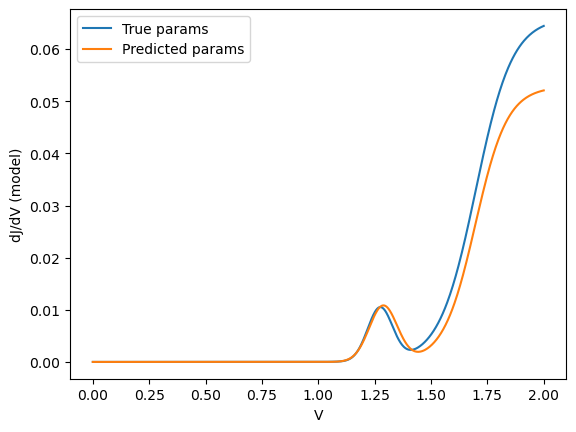

Pt          0.238000
Pd          0.090200
Au          0.581200
Ir          0.090500
k          11.848427
V0          1.725884
u1          1.345130
s1          0.046855
A1          0.063128
A2          0.004403
k_pred     13.263376
V0_pred     1.700350
u1_pred     1.327522
s1_pred     0.066892
A1_pred     0.051209
A2_pred     0.006953
Name: 27, dtype: float64


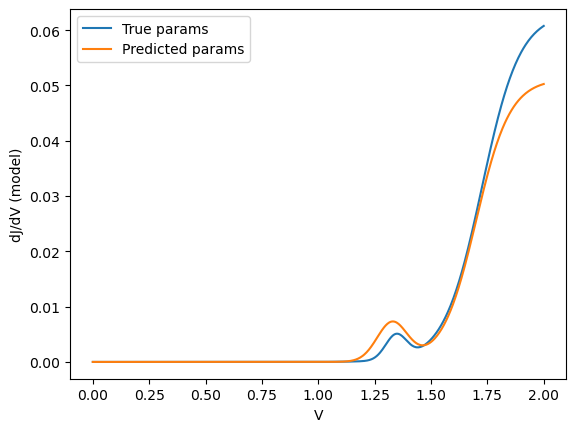

Pt          0.159900
Pd          0.245000
Au          0.448100
Ir          0.147100
k           4.501851
V0          2.000000
u1          1.366135
s1          0.048310
A1          0.115604
A2          0.010473
k_pred     10.493250
V0_pred     1.770542
u1_pred     1.370029
s1_pred     0.067336
A1_pred     0.071898
A2_pred     0.013886
Name: 28, dtype: float64


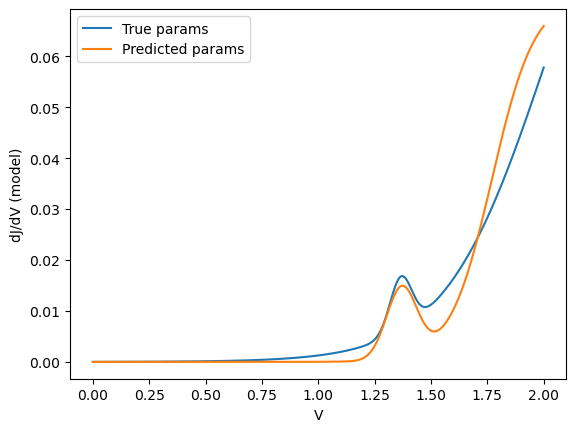

Pt          0.156800
Pd          0.094100
Au          0.582600
Ir          0.166500
k          12.536635
V0          1.694815
u1          1.365654
s1          0.053221
A1          0.063001
A2          0.017326
k_pred     10.753852
V0_pred     1.760452
u1_pred     1.371249
s1_pred     0.060719
A1_pred     0.066682
A2_pred     0.014901
Name: 29, dtype: float64


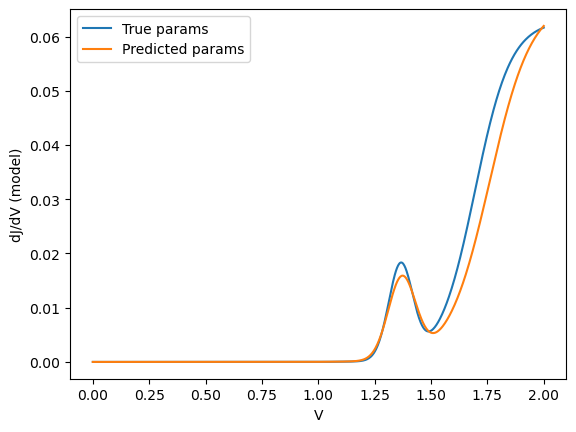

Pt         0.062400
Pd         0.376000
Au         0.230700
Ir         0.330900
k          8.877966
V0         1.540500
u1         1.400349
s1         0.086977
A1         0.050915
A2         0.030592
k_pred     8.607056
V0_pred    1.682626
u1_pred    1.403575
s1_pred    0.092034
A1_pred    0.062774
A2_pred    0.030886
Name: 30, dtype: float64


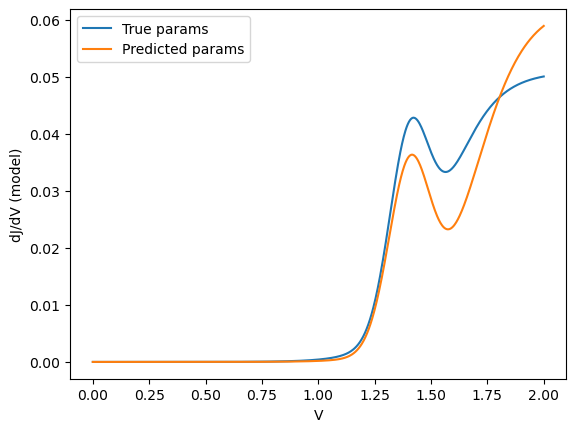

Pt          0.123200
Pd          0.067900
Au          0.659900
Ir          0.149000
k          13.689412
V0          1.679297
u1          1.376332
s1          0.055137
A1          0.042461
A2          0.014693
k_pred     10.678060
V0_pred     1.788560
u1_pred     1.376749
s1_pred     0.062518
A1_pred     0.077683
A2_pred     0.014871
Name: 31, dtype: float64


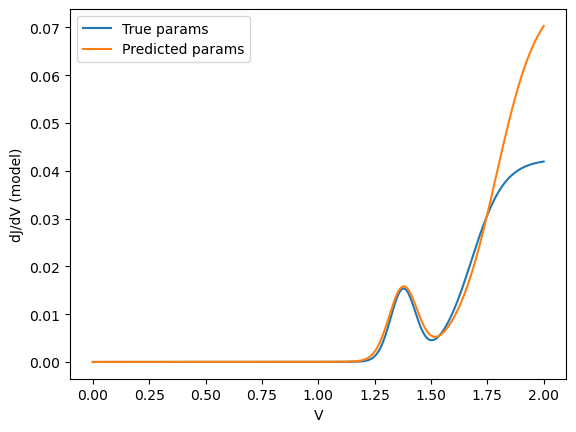

Pt          0.259100
Pd          0.162600
Au          0.064100
Ir          0.514200
k          13.341571
V0          1.514878
u1          1.405887
s1          0.100534
A1          0.035304
A2          0.034068
k_pred     25.805959
V0_pred     1.516342
u1_pred     1.411313
s1_pred     0.105748
A1_pred     0.033446
A2_pred     0.035041
Name: 32, dtype: float64


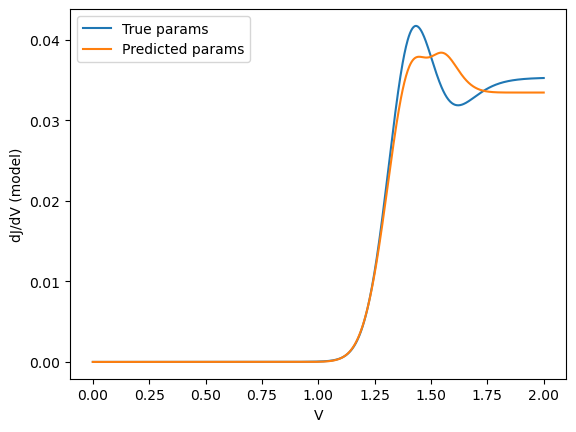

Pt          0.566500
Pd          0.095000
Au          0.316900
Ir          0.021600
k          11.507491
V0          1.617027
u1          1.283759
s1          0.053758
A1          0.020479
A2          0.002149
k_pred     11.915535
V0_pred     1.680917
u1_pred     1.271052
s1_pred     0.049222
A1_pred     0.048759
A2_pred     0.006475
Name: 33, dtype: float64


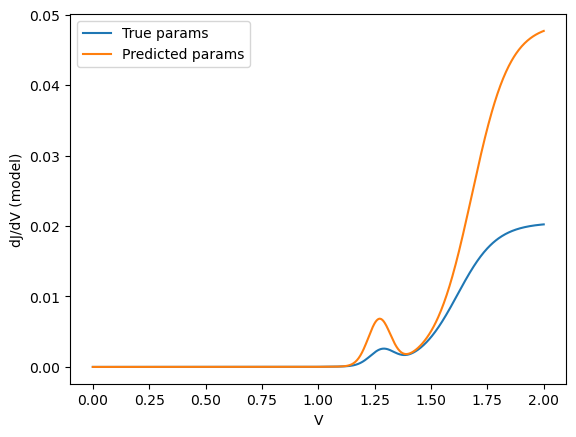

Pt          0.463600
Pd          0.097200
Au          0.399400
Ir          0.039800
k          11.043865
V0          1.695062
u1          1.281340
s1          0.041803
A1          0.057291
A2          0.002512
k_pred     12.185291
V0_pred     1.678648
u1_pred     1.280679
s1_pred     0.052057
A1_pred     0.044312
A2_pred     0.005303
Name: 34, dtype: float64


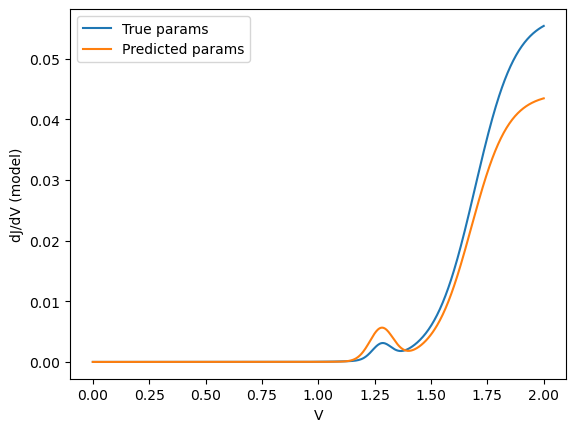

Pt          0.374200
Pd          0.114400
Au          0.455000
Ir          0.056400
k          15.987552
V0          1.685056
u1          1.273774
s1          0.066932
A1          0.049154
A2          0.017950
k_pred     12.201295
V0_pred     1.690855
u1_pred     1.297722
s1_pred     0.057498
A1_pred     0.046127
A2_pred     0.004988
Name: 35, dtype: float64


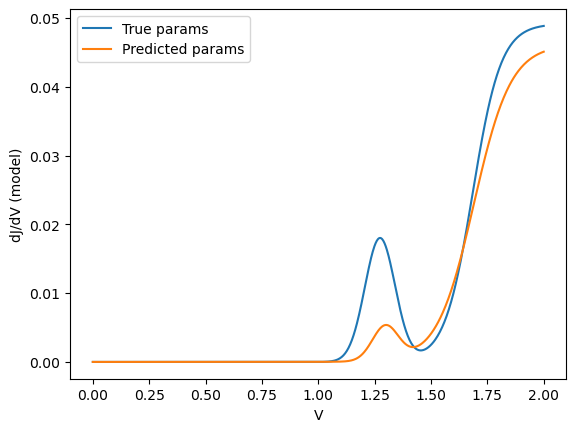

Pt          0.094300
Pd          0.095900
Au          0.119200
Ir          0.690600
k          25.538608
V0          1.587280
u1          1.451662
s1          0.131399
A1          0.037769
A2          0.047514
k_pred     25.230196
V0_pred     1.531980
u1_pred     1.427203
s1_pred     0.114933
A1_pred     0.032858
A2_pred     0.035968
Name: 36, dtype: float64


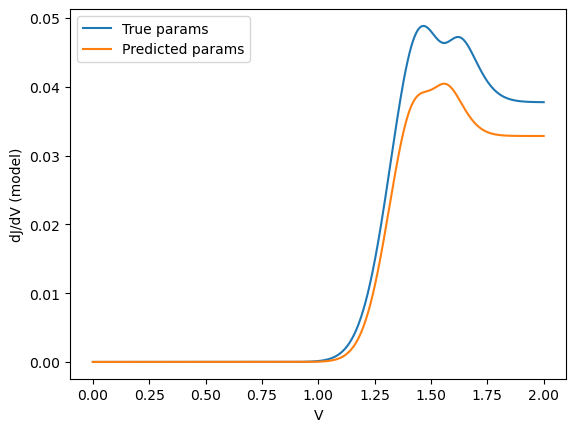

Pt          0.051200
Pd          0.072300
Au          0.463800
Ir          0.412700
k           8.941126
V0          1.639625
u1          1.430916
s1          0.110186
A1          0.051418
A2          0.045377
k_pred     20.902221
V0_pred     1.523990
u1_pred     1.420886
s1_pred     0.103858
A1_pred     0.043967
A2_pred     0.028688
Name: 37, dtype: float64


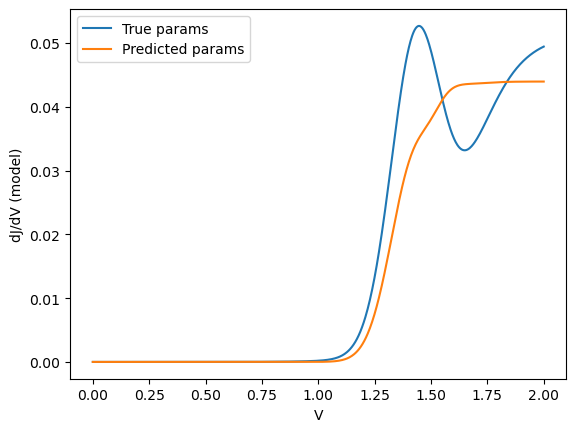

Pt          0.607600
Pd          0.124300
Au          0.255700
Ir          0.012400
k          10.647106
V0          1.678393
u1          1.264084
s1          0.043176
A1          0.042557
A2          0.003685
k_pred     11.887860
V0_pred     1.685781
u1_pred     1.268580
s1_pred     0.048921
A1_pred     0.050572
A2_pred     0.006910
Name: 38, dtype: float64


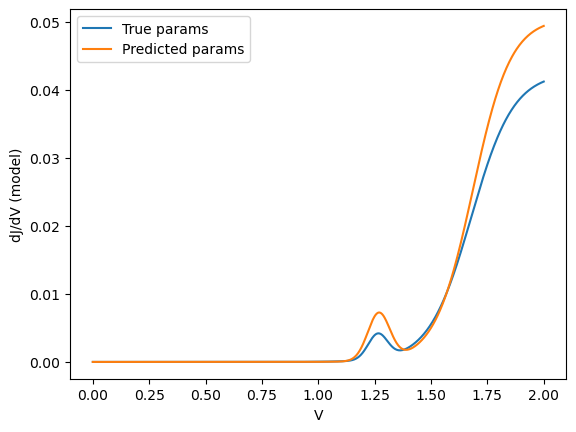

Pt          0.305000
Pd          0.088200
Au          0.044600
Ir          0.562100
k          33.646440
V0          1.402384
u1          1.326804
s1          0.069941
A1          0.022477
A2          0.011936
k_pred     24.666912
V0_pred     1.535135
u1_pred     1.426605
s1_pred     0.114792
A1_pred     0.033030
A2_pred     0.035470
Name: 39, dtype: float64


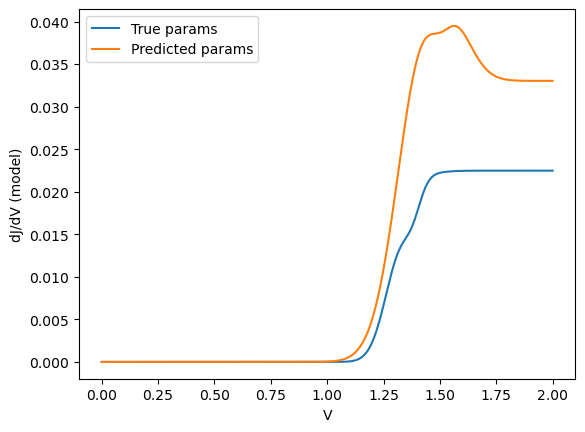

Pt          0.233100
Pd          0.357800
Au          0.319600
Ir          0.089500
k          13.550510
V0          1.682659
u1          1.377006
s1          0.084141
A1          0.060726
A2          0.026404
k_pred     15.755034
V0_pred     1.700508
u1_pred     1.320511
s1_pred     0.080359
A1_pred     0.054081
A2_pred     0.012465
Name: 40, dtype: float64


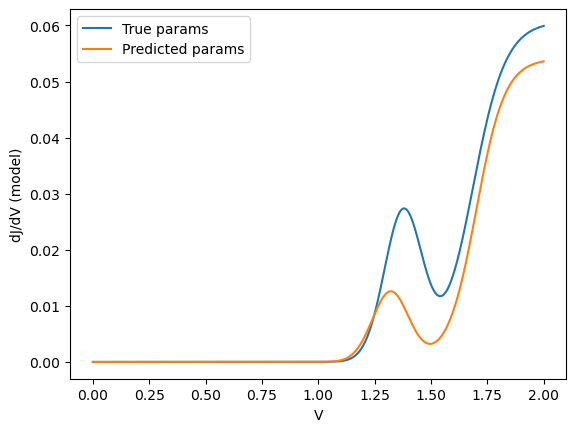

Pt          0.252900
Pd          0.147800
Au          0.511200
Ir          0.088100
k          12.222088
V0          1.691110
u1          1.357648
s1          0.053647
A1          0.036331
A2          0.004651
k_pred     13.252561
V0_pred     1.706176
u1_pred     1.321943
s1_pred     0.066361
A1_pred     0.054162
A2_pred     0.007487
Name: 41, dtype: float64


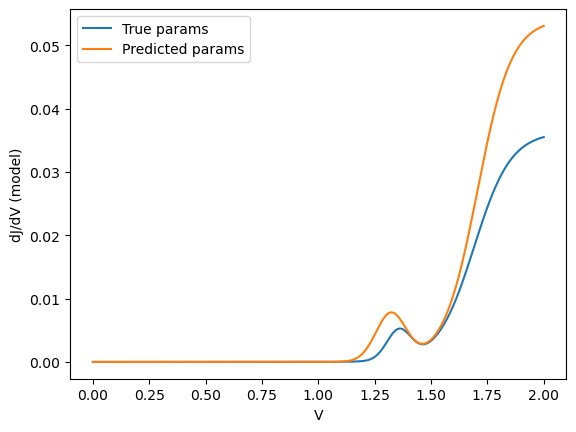

Pt          0.158900
Pd          0.189000
Au          0.459600
Ir          0.192400
k          11.850837
V0          1.691588
u1          1.365970
s1          0.068416
A1          0.063540
A2          0.021573
k_pred      9.874468
V0_pred     1.778037
u1_pred     1.380277
s1_pred     0.069018
A1_pred     0.074001
A2_pred     0.020135
Name: 42, dtype: float64


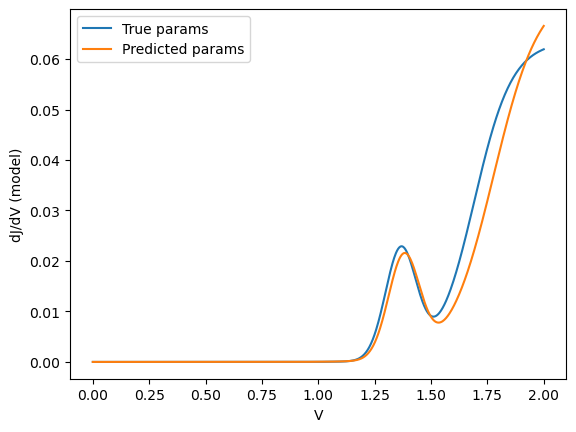

Pt          0.109000
Pd          0.300700
Au          0.157400
Ir          0.432900
k           9.922974
V0          1.591903
u1          1.415380
s1          0.101530
A1          0.042299
A2          0.026855
k_pred     15.702499
V0_pred     1.548227
u1_pred     1.409375
s1_pred     0.101530
A1_pred     0.041677
A2_pred     0.033261
Name: 43, dtype: float64


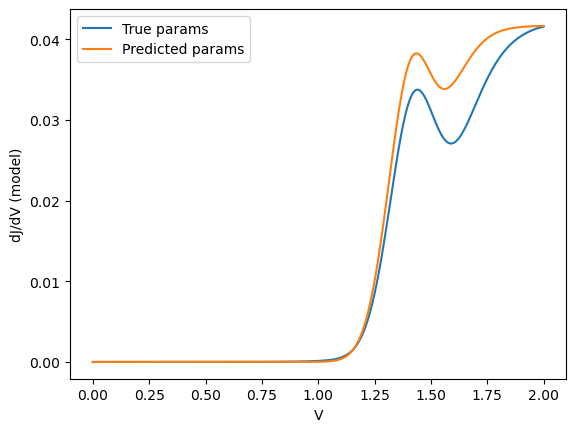

Pt         0.062800
Pd         0.101900
Au         0.504400
Ir         0.330900
k          8.601573
V0         1.562028
u1         1.418934
s1         0.095143
A1         0.043421
A2         0.031494
k_pred     9.339104
V0_pred    1.737121
u1_pred    1.406454
s1_pred    0.088246
A1_pred    0.068777
A2_pred    0.031627
Name: 44, dtype: float64


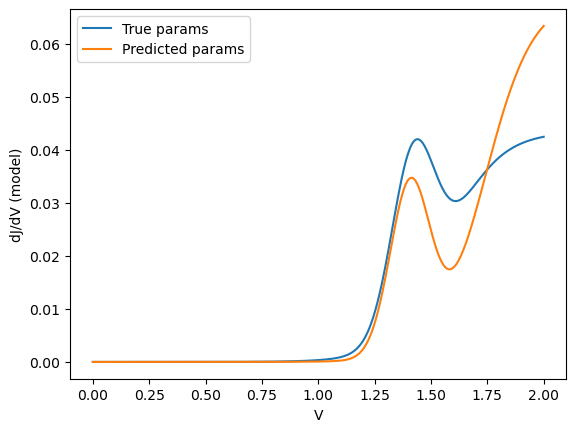

Pt          0.327500
Pd          0.151000
Au          0.445800
Ir          0.075800
k          10.603388
V0          1.730386
u1          1.300044
s1          0.052990
A1          0.056751
A2          0.003384
k_pred     12.420313
V0_pred     1.702031
u1_pred     1.302928
s1_pred     0.060670
A1_pred     0.051192
A2_pred     0.005994
Name: 45, dtype: float64


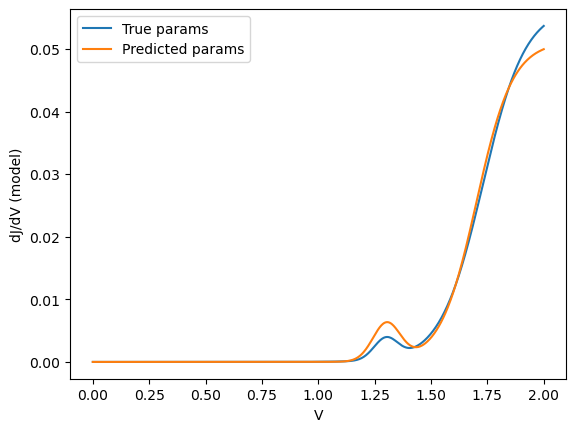

Pt          0.104000
Pd          0.070400
Au          0.095800
Ir          0.729800
k          27.126573
V0          1.573988
u1          1.449134
s1          0.125434
A1          0.033556
A2          0.041439
k_pred     25.218190
V0_pred     1.531715
u1_pred     1.427610
s1_pred     0.115121
A1_pred     0.032847
A2_pred     0.035871
Name: 46, dtype: float64


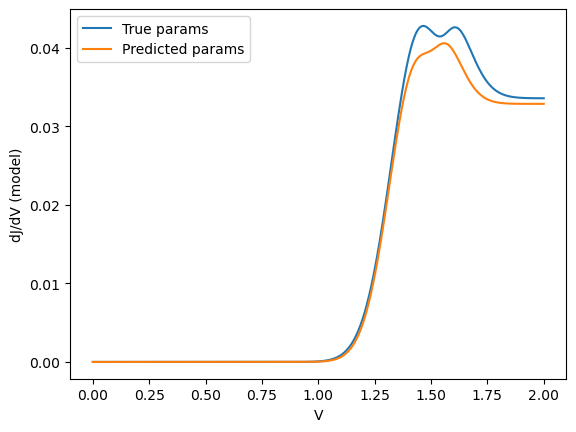

Pt          0.433500
Pd          0.198100
Au          0.328000
Ir          0.040300
k          13.223159
V0          1.697127
u1          1.284075
s1          0.043643
A1          0.039055
A2          0.004895
k_pred     11.656771
V0_pred     1.695433
u1_pred     1.268208
s1_pred     0.049429
A1_pred     0.054442
A2_pred     0.007700
Name: 47, dtype: float64


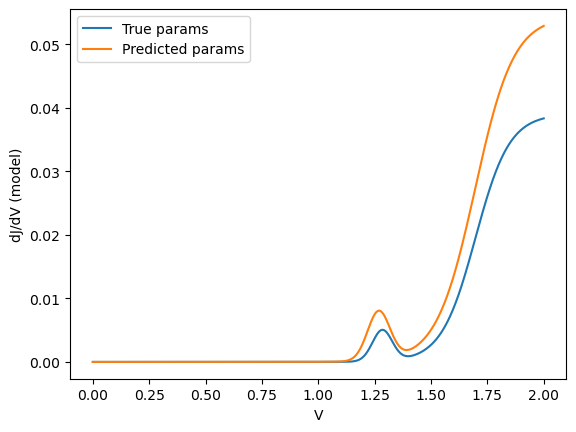

Pt          0.195100
Pd          0.354500
Au          0.347000
Ir          0.103500
k          11.607057
V0          1.681526
u1          1.342818
s1          0.077034
A1          0.048318
A2          0.012439
k_pred     13.970292
V0_pred     1.719801
u1_pred     1.393292
s1_pred     0.121500
A1_pred     0.063954
A2_pred     0.008306
Name: 48, dtype: float64


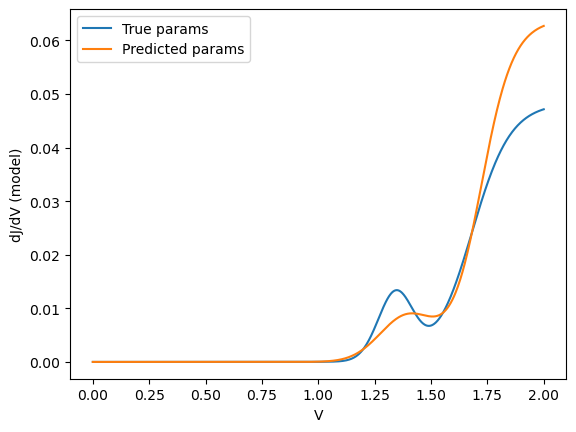

Pt          0.063900
Pd          0.095700
Au          0.163800
Ir          0.676600
k          27.094448
V0          1.528809
u1          1.419285
s1          0.111875
A1          0.039085
A2          0.043154
k_pred     25.288702
V0_pred     1.527840
u1_pred     1.427678
s1_pred     0.115075
A1_pred     0.032876
A2_pred     0.035681
Name: 49, dtype: float64


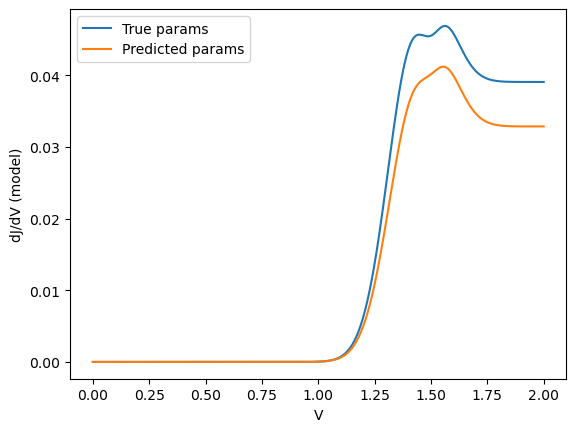

In [9]:
# ── Model functions (must match dJdVpreprocess.ipynb) ────────────────────────

def logistic(V, k, V0):
    return 1.0 / (1.0 + np.exp(-k * (V - V0)))

def hump(V, u, s):
    return np.exp(-((V - u) ** 2) / (2.0 * s ** 2))

def djdv_model(V, p):
    k, V0, u1, s1, A1, A2 = p
    return A1 * logistic(V, k, V0) + A2 * hump(V, u1, s1)

TRUE_COLS = Y_COLS
PRED_COLS = [f'{c}_pred' for c in Y_COLS]

def plot_true_vs_pred(row, V_min=0.0, V_max=2.0, n_pts=800):
    V_grid = np.linspace(V_min, V_max, n_pts)
    p_true = row[TRUE_COLS].to_numpy(dtype=float)
    p_pred = row[PRED_COLS].to_numpy(dtype=float)

    fig, ax = plt.subplots()
    ax.plot(V_grid, djdv_model(V_grid, p_true), label='True params')
    ax.plot(V_grid, djdv_model(V_grid, p_pred), label='Predicted params')
    ax.set_xlabel('V')
    ax.set_ylabel('dJ/dV (model)')
    if 'sample_id' in row.index:
        ax.set_title(f'sample_id = {int(row["sample_id"])}')
    ax.legend()
    plt.show()

for _, row in results_df.iterrows():
    print(row)
    plot_true_vs_pred(row)


## 6. Quaternary Simplex Visualizations

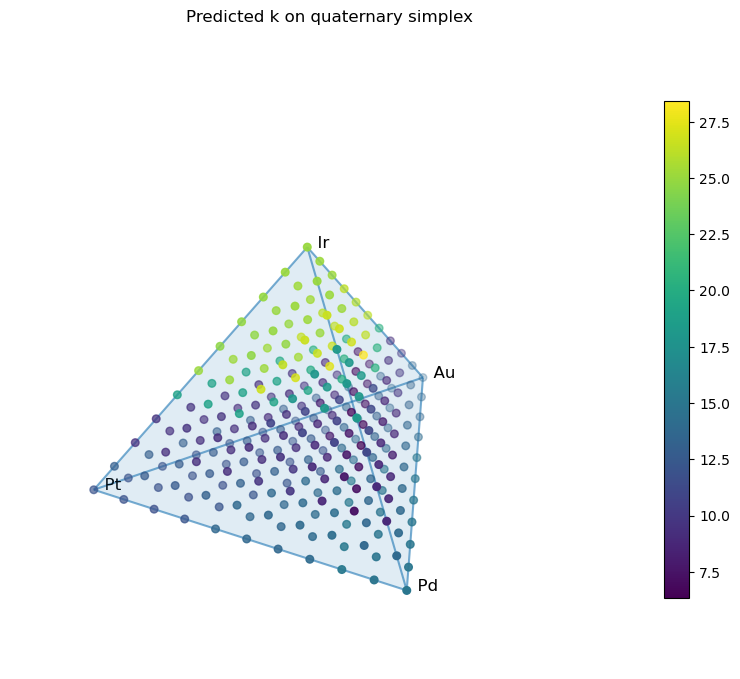

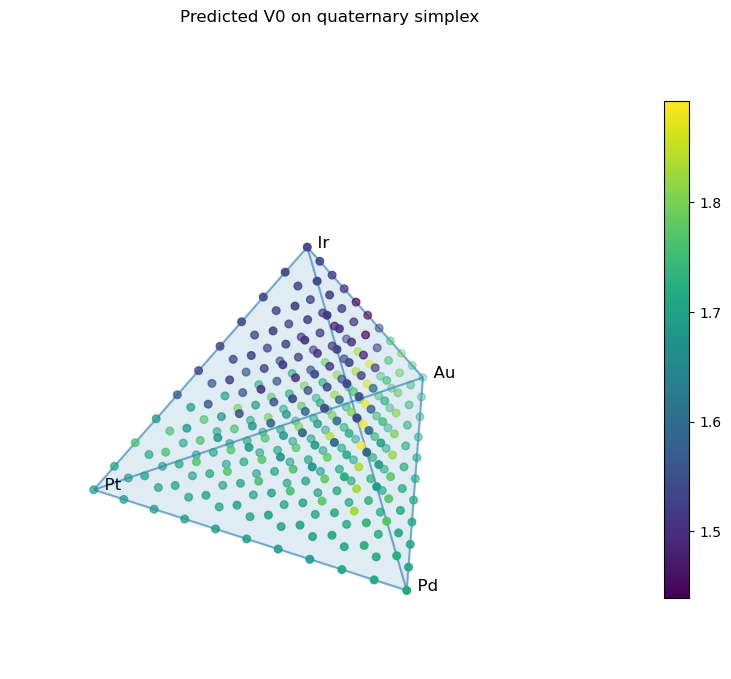

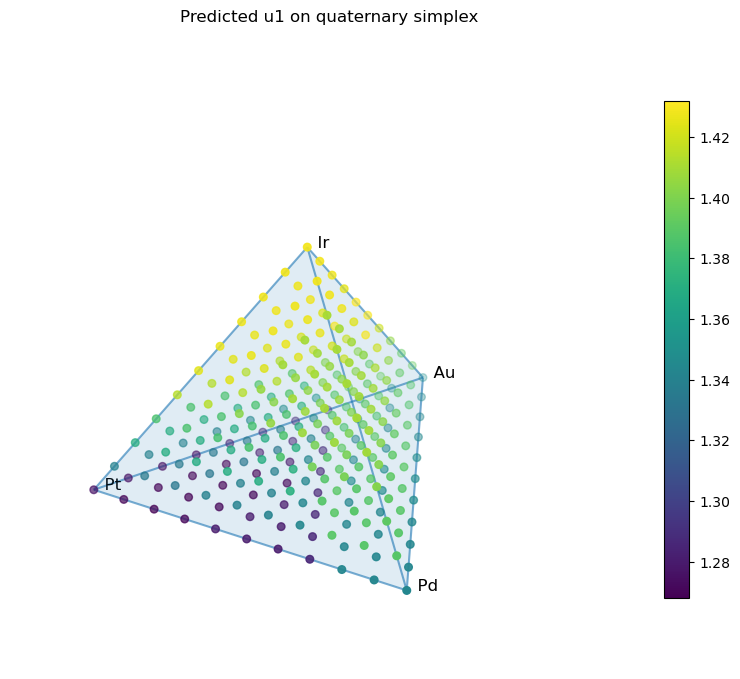

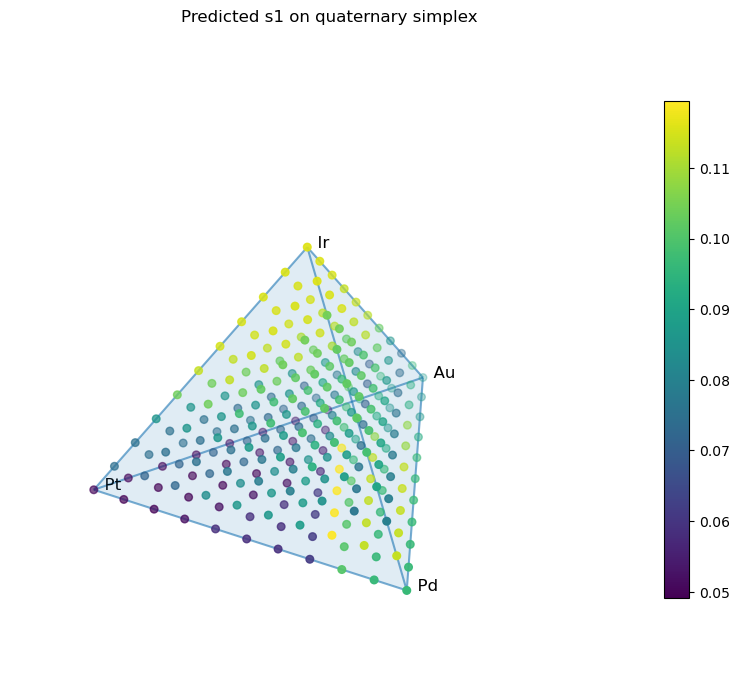

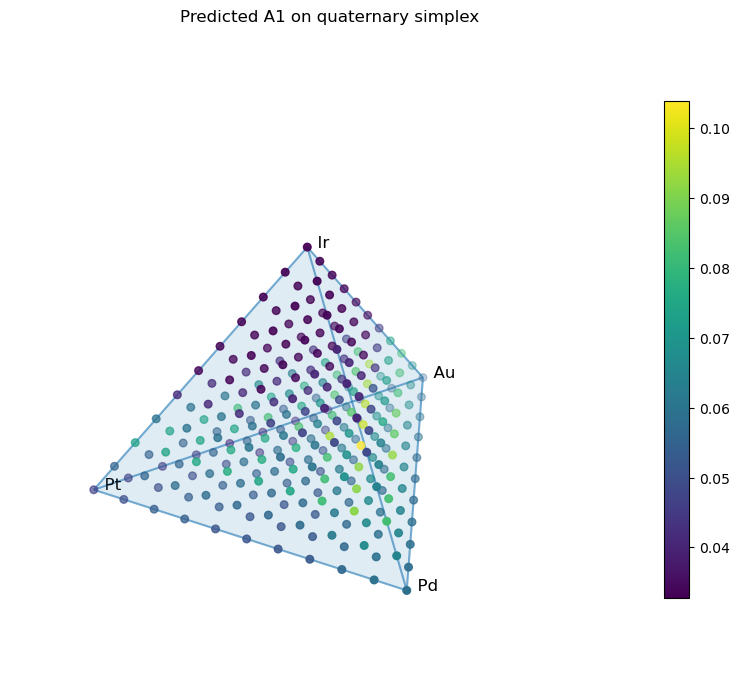

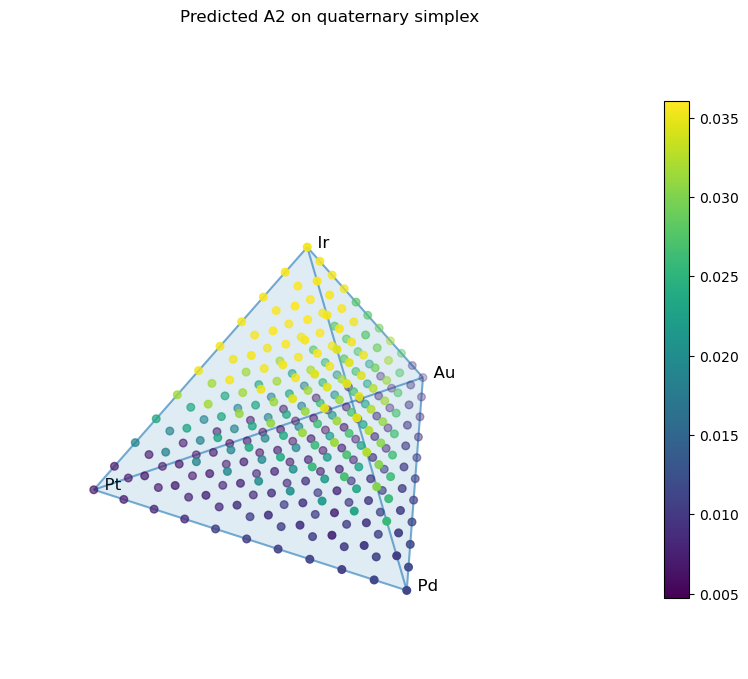

In [10]:
# ── Tetrahedron vertices (Pt, Pd, Au, Ir) ────────────────────────────────────
sqrt3 = np.sqrt(3.0)
VERTICES = np.array([
    [0.0,       0.0,          0.0                ],   # Pt
    [1.0,       0.0,          0.0                ],   # Pd
    [0.5,  sqrt3 / 2,         0.0                ],   # Au
    [0.5,  sqrt3 / 6,  np.sqrt(2.0 / 3.0)       ],   # Ir
])

def simplex_lattice(step=0.1):
    """All 4-tuples on the quaternary simplex at the given step size."""
    n     = int(round(1.0 / step))
    comps = []
    for a in range(n + 1):
        for b in range(n + 1 - a):
            for c in range(n + 1 - a - b):
                d = n - a - b - c
                comps.append([a, b, c, d])
    return np.array(comps, dtype=float) / n   # shape (N, 4), rows sum to 1

def barycentric_to_cartesian(comps):
    """Map (N, 4) barycentric coordinates to (N, 3) Cartesian via VERTICES."""
    return comps @ VERTICES

comps = simplex_lattice(step=0.1)
xyz   = barycentric_to_cartesian(comps)

def plot_quaternary_tetra(xyz, values, title, ax=None, cmap='viridis', s=30):
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection

    if ax is None:
        fig = plt.figure(figsize=(8, 7))
        ax  = fig.add_subplot(111, projection='3d')

    Vp, Vpd, Vau, Vir = VERTICES

    edges = [
        (Vp, Vpd), (Vp, Vau), (Vp, Vir),
        (Vpd, Vau), (Vpd, Vir),
        (Vau, Vir),
    ]
    ax.add_collection3d(Line3DCollection(edges, linewidths=1.5, alpha=0.6))

    faces = [
        [Vp, Vpd, Vau],
        [Vp, Vpd, Vir],
        [Vp, Vau, Vir],
        [Vpd, Vau, Vir],
    ]
    ax.add_collection3d(Poly3DCollection(faces, alpha=0.07))

    norm = Normalize(vmin=np.nanmin(values), vmax=np.nanmax(values))
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2],
               c=values, cmap=cmap, norm=norm, s=s, depthshade=True)

    for label, vert in zip(['Pt', 'Pd', 'Au', 'Ir'], VERTICES):
        ax.text(vert[0], vert[1], vert[2], f'  {label}', fontsize=12)

    ax.set_axis_off()
    ax.set_title(title)
    plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.75, pad=0.02)
    return ax

# ── Predict on the simplex lattice ────────────────────────────────────────────
X_lattice = pd.DataFrame(comps, columns=X_COLS)
Y_lattice = best_model.predict(X_lattice.values)   # (N, 6)

for j, param_name in enumerate(Y_COLS):
    fig = plt.figure(figsize=(8, 7))
    ax  = fig.add_subplot(111, projection='3d')
    plot_quaternary_tetra(xyz, Y_lattice[:, j],
                          title=f'Predicted {param_name} on quaternary simplex', ax=ax)
    plt.tight_layout()
    plt.savefig(f'quaternary_{param_name}.pdf', format='pdf', bbox_inches='tight')
    plt.show()
